In [147]:
import pandas as pd
df = pd.read_csv('/content/StudentPerformance.csv')
df.head()

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [148]:
df.shape

(10000, 6)

In [149]:
df.tail()

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question Papers_Practiced,Performance_Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [150]:
df.sample(8)

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question Papers_Practiced,Performance_Index
3962,6,96,Yes,6,4,85.0
9450,3,80,No,7,6,59.0
767,2,45,No,4,4,18.0
6286,7,65,Yes,6,7,56.0
9067,7,70,No,7,3,61.0
624,7,54,Yes,4,5,42.0
5800,7,52,Yes,6,9,48.0
6653,2,62,No,4,8,40.0


In [151]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours_Studied                     10000 non-null  int64  
 1   Previous_Scores                   10000 non-null  int64  
 2   Extracurricular_Activities        10000 non-null  object 
 3   Sleep_Hours                       10000 non-null  int64  
 4   Sample_Question Papers_Practiced  10000 non-null  int64  
 5   Performance_Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [152]:
df.Extracurricular_Activities = df.Extracurricular_Activities.map({'Yes' : 1,'No' : 0}) # df['Extracurricular_Activities']
df.info()
df.sample(9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours_Studied                     10000 non-null  int64  
 1   Previous_Scores                   10000 non-null  int64  
 2   Extracurricular_Activities        10000 non-null  int64  
 3   Sleep_Hours                       10000 non-null  int64  
 4   Sample_Question Papers_Practiced  10000 non-null  int64  
 5   Performance_Index                 10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question Papers_Practiced,Performance_Index
1576,8,94,1,6,5,90.0
3998,6,93,0,7,0,82.0
1319,5,58,0,6,3,40.0
1585,1,88,1,4,5,63.0
9230,7,42,1,8,1,29.0
5509,6,97,0,8,7,92.0
8171,4,92,1,4,0,74.0
1382,5,98,1,5,8,83.0
412,7,41,1,8,3,34.0


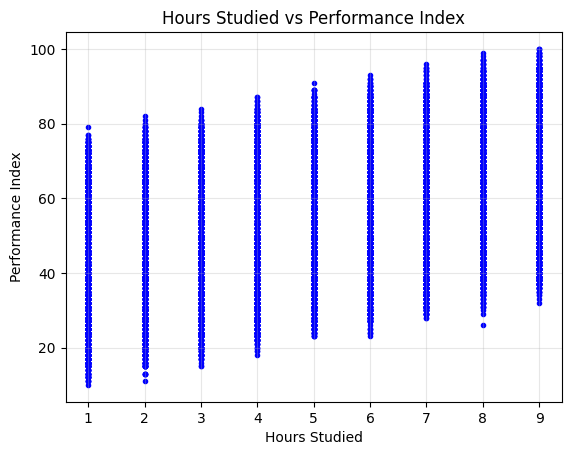

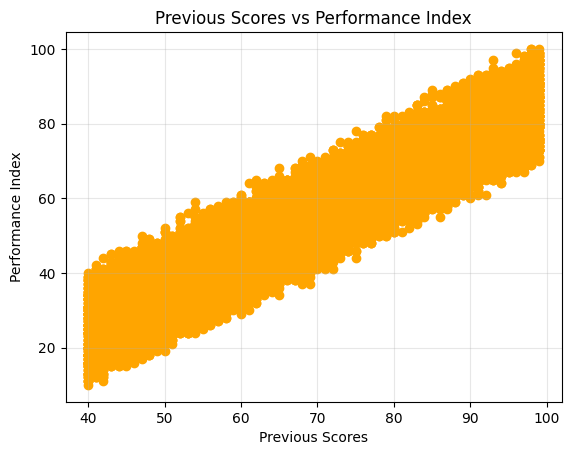

In [153]:
import matplotlib.pyplot as plt
# Hours Studied
plt.scatter(df.Hours_Studied, df.Performance_Index, marker='.', color='blue')
plt.xlabel('Hours Studied')
plt.ylabel('Performance Index')
plt.title('Hours Studied vs Performance Index')
plt.grid(True, alpha=0.3)
plt.show()

# Previous Scores
plt.scatter(df.Previous_Scores, df.Performance_Index, marker='o', color='orange')
plt.xlabel('Previous Scores')
plt.ylabel('Performance Index')
plt.title('Previous Scores vs Performance Index')
plt.grid(True, alpha=0.3)
plt.show()




In [154]:
x = df.drop('Performance_Index',axis='columns')
y = df.Performance_Index
print(x)
print(y)

      Hours_Studied  Previous_Scores  Extracurricular_Activities  Sleep_Hours  \
0                 7               99                           1            9   
1                 4               82                           0            4   
2                 8               51                           1            7   
3                 5               52                           1            5   
4                 7               75                           0            8   
...             ...              ...                         ...          ...   
9995              1               49                           1            4   
9996              7               64                           1            8   
9997              6               83                           1            8   
9998              9               97                           1            7   
9999              7               74                           0            8   

      Sample_Question Paper

In [155]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=20,test_size=0.2)
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [156]:
print(model.score(x_train,y_train))
print(model.score(x_test,y_test))  # modelunderfit

0.9887772085802176
0.9886431915463552


In [157]:
model.predict(pd.DataFrame([[7, 99, 1, 9, 1]],
                          columns=['Hours_Studied', 'Previous_Scores',
                                   'Extracurricular_Activities', 'Sleep_Hours',
                                   'Sample_Question Papers_Practiced']))

array([91.85808189])

In [158]:
y_predict = model.predict(x_test)
y_predict

array([55.9980763 , 27.56612423, 47.8726458 , ..., 18.58554207,
       73.02855382, 91.42097182])

In [159]:
cm = pd.DataFrame({'Actual' : y_test, 'Predicted' : y_predict})
cm

,Actual,Predicted
9957,59.0,55.998076
1687,26.0,27.566124
2116,46.0,47.872646
231,88.0,89.776193
2780,78.0,76.965792
...,...,...
7176,53.0,53.663971
5050,56.0,56.677650
7910,18.0,18.585542
7023,72.0,73.028554


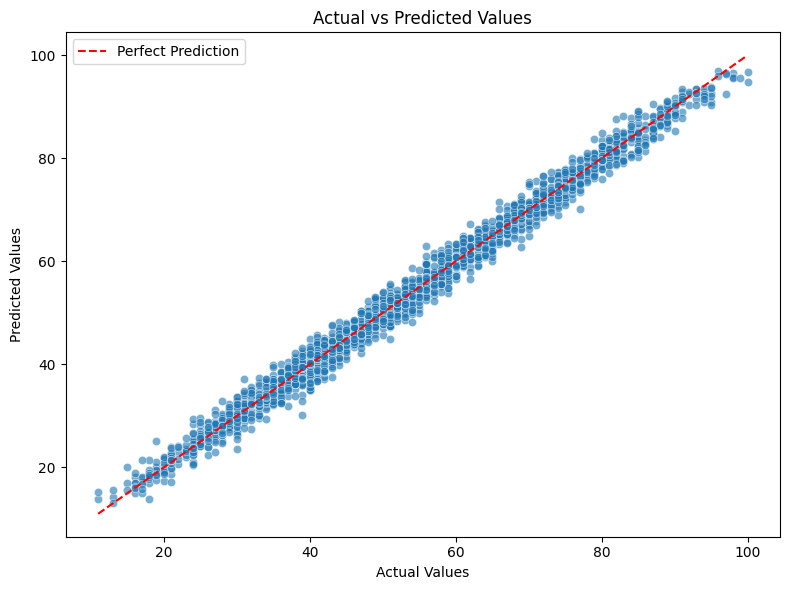

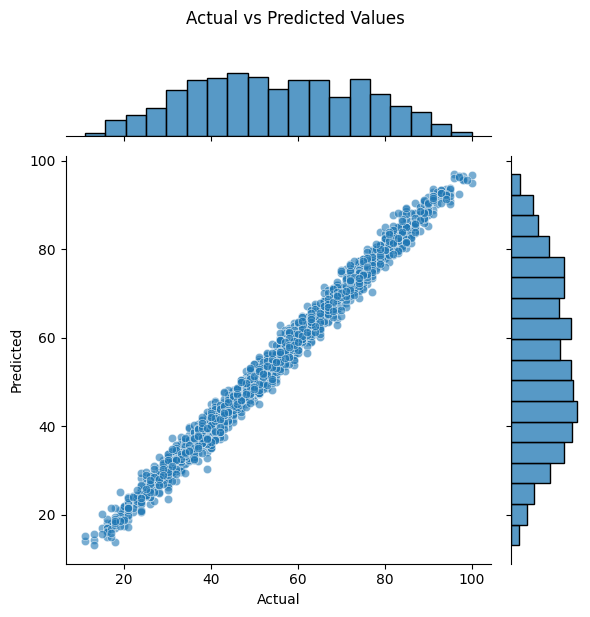

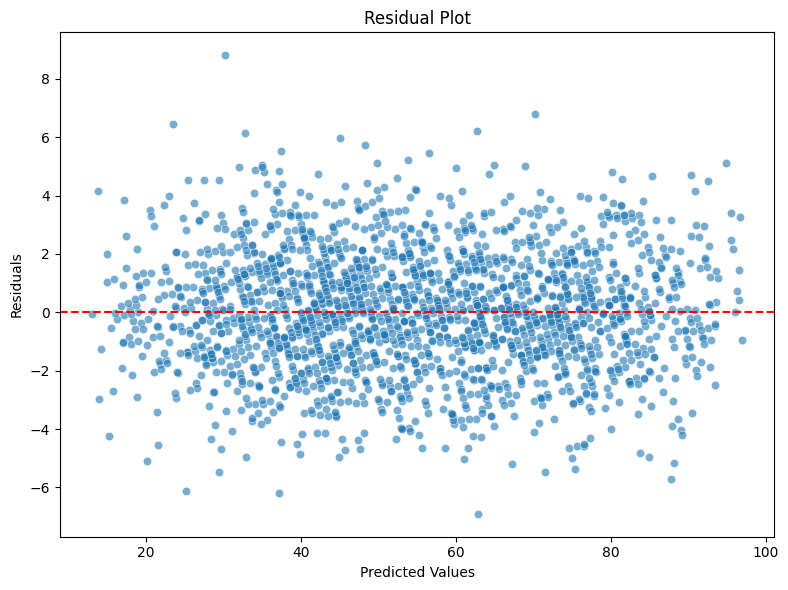

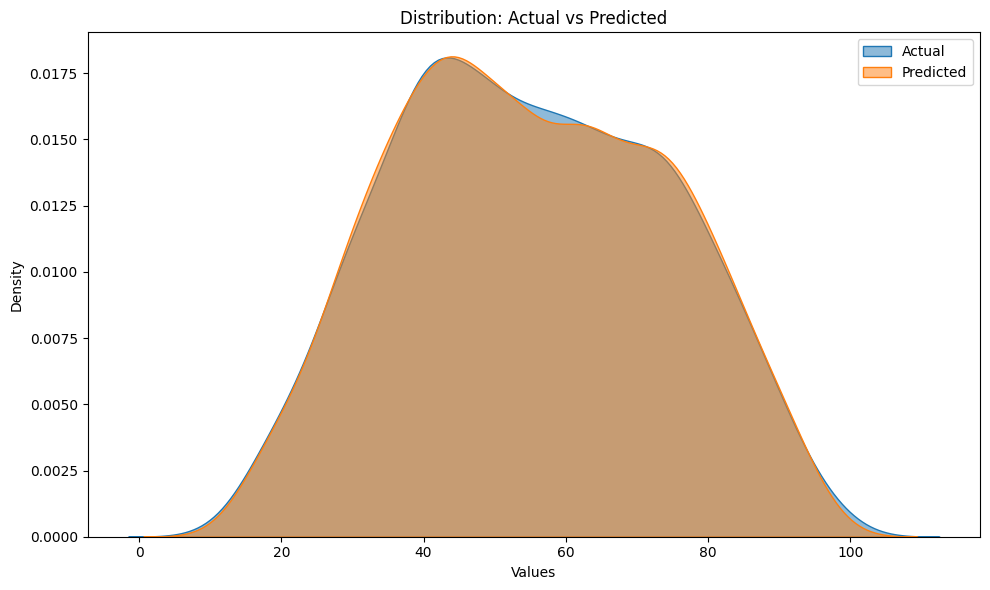

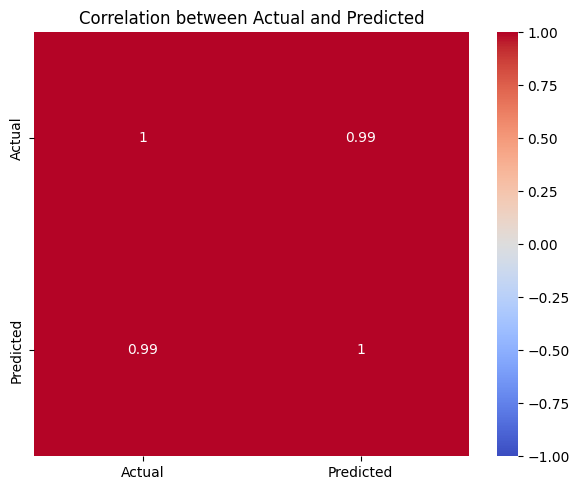

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the dataframe
cm = pd.DataFrame({'Actual': y_test, 'Predicted': y_predict})

# 1. Scatter plot (most common for regression)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=cm, x='Actual', y='Predicted', alpha=0.6)
plt.plot([cm.min().min(), cm.max().max()], [cm.min().min(), cm.max().max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Joint plot with histograms
sns.jointplot(data=cm, x='Actual', y='Predicted', kind='scatter', alpha=0.6)
plt.suptitle('Actual vs Predicted Values', y=1.02)
plt.tight_layout()
plt.show()

# 3. Residual plot (difference between actual and predicted)
cm['Residuals'] = cm['Actual'] - cm['Predicted']
plt.figure(figsize=(8, 6))
sns.scatterplot(data=cm, x='Predicted', y='Residuals', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

# 4. Distribution comparison
plt.figure(figsize=(10, 6))
sns.kdeplot(data=cm, x='Actual', label='Actual', fill=True, alpha=0.5)
sns.kdeplot(data=cm, x='Predicted', label='Predicted', fill=True, alpha=0.5)
plt.xlabel('Values')
plt.ylabel('Density')
plt.title('Distribution: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Simple heatmap of correlation
plt.figure(figsize=(6, 5))
sns.heatmap(cm[['Actual', 'Predicted']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation between Actual and Predicted')
plt.tight_layout()
plt.show()

In [168]:
# Save the model to Colab's temporary storage
with open('model_pickle.pkl', 'wb') as file:
    pickle.dump(model, file)

print("Model saved as 'model_pickle.pkl'")

Model saved as 'model_pickle.pkl'


In [169]:
import joblib

# Save model
joblib.dump(model, 'model_joblib.pkl')

# Download to local machine
from google.colab import files
files.download('model_joblib.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>